# Homework 10 - Chapter 15

- Due Date: Friday, April 17th no later than 11:59 p.m.
- Partner Information: You may complete this assignment individually or with exactly one classmate.
- Submission Instructions (working alone): Upload your solution, entitled **YourFirstName-YourLastName-Homework10.ipynb** to the 
Canvas Homework 10 Dropbox.
- Submission Instructions (working with one classmate): Upload your solution, entitled 
**YourFirstName-YourLastName-PartnerFirstName-PartnerLastName-Homework10.ipynb** to the Canvas Homework 10 Dropbox. Note: If you 
work with a partner, only one person needs to submit a solution. If you both submit a solution, the submission that will be graded is the one 
from the partner whose last name comes alphabetically first.
- Deadline Reminder: Once the submission deadline passes, Canvas will no longer accept your submission and you will no longer be able to earn credit. 
Thus, if you are not able to fully complete the assignment, submit whatever you have before the deadline so that partial credit can be earned.

## Starting Code

In [16]:
from datascience import *
import numpy as np
import matplotlib.pyplot as plots
%matplotlib inline

Download the file [golf.csv]()
into the same directory as this Jupyter notebook.

In [2]:
# Place the csv file in the same directory as your solution
golf = Table().read_table("golf.csv")
golf.show(3)

Date,Weekday,Holiday,Month,Season,Temperature,Humidity,Windy,Outlook,Crowdedness
2021-01-01,4,1,Jan,Winter,3.3,49,1,sunny,0.73
2021-01-02,5,0,Jan,Winter,2.9,53,0,sunny,0.74
2021-01-03,6,0,Jan,Winter,2.3,58,0,overcast,0.7


## Question 1a - 1 Points

The Master's is a storied May golf tournament that has been played since 1934. Many legendary golfers have won it and been rewarded with a Green Jacket, the latest being Rory McIlroy. Being the first "Major" tournament of the PGA season, it signifies the start of the golf season to many. Unlike in Augusta Georgia, where the Master's takes place, golfers in Montana can only play during the warm-weather months. This causes many people to travel to warmer climates to hit the course any time of the year. You have been hired by a golf course in one of these warmer climates, and the course management wants to know how environmental factors influence how busy their greens get.

You’ve been asked to explore how **Temperature** affects the **Crowdedness** of the course. First, convert the **Temperature** and **Crowdedness** columns into standard units, and add these as new columns called **Standardized Temperature** and **Standardized Crowdedness**, respectively. Then, display a scatterplot of **Standardized Temperature** and **Standardized Crowdedness**.

In [4]:
def standard_units(numbers):
    "Convert any array of numbers to standard units."
    return (numbers - np.mean(numbers))/np.std(numbers)    

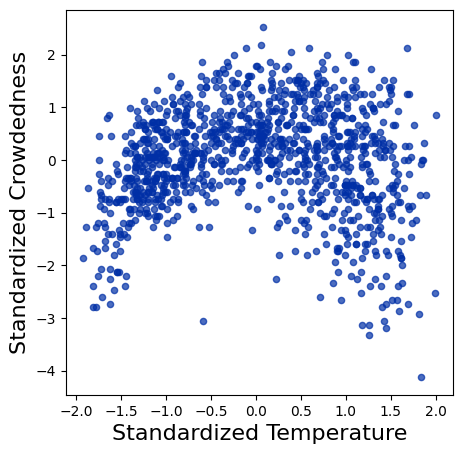

In [6]:
standardized_data = Table().with_columns(
    'Standardized Temperature',  standard_units(golf.column('Temperature')), 
    'Standardized Crowdedness', standard_units(golf.column('Crowdedness'))
)
standardized_data.scatter(0, 1)

## Question 1b - 1 Point

The course management wants to see how associated these two values are mathematically. Calculate *r* (the correlation coefficient) of the columns **Standardized Temperature** and **Standardized Crowdedness**, and print it in the following format where d is a digit: *The correlation between Standardized Temperature and Standardized Crowdedness is: 0.dd*

In [8]:
r = np.mean(standardized_data.column("Standardized Temperature") * standardized_data.column("Standardized Crowdedness"))
print(f"The correlation between Standardized Temperature and Standardized Crowdedness is: {r:.2f}")

The correlation between Standardized Temperature and Standardized Crowdedness is: 0.01


## Question 1c - 1 Point

Do you believe that the correlation coefficient accurately shows the relationship between the two variables? Explain why or why not, using information from the textbook to support your answer.

**Your Answer Here -** No, I do not think the correlation coefficient accurately shows the relationship between the standardized temperature and crowdedness. I believe this is because correlation only measures linear association. Based on our plot above, it appears that we might have a quadratic pattern. Because of that, correlation may still be small even though the variables are strongly associated.

## Question 2a - 2 Points

After seeing the correlation coefficient you calculated, the course management is ready to move on. However, using your worth-its-weight-in-gold data science knowledge, you know that crowdedness and temperature are associated. To begin to convince the management, you have decided to show them some visual diagnostics.

Create a column for the residuals of the linear equation that best predicts the **Standardized Crowdedness** from the **Standardized Temperature**, using the correlation coefficient function that you wrote previously. Add these values to the table in a new column called **Residuals**, and create a scatterplot that shows the relationship between **Standardized Temperature** and **Residuals**.

In [18]:
def correlation(t, label_x, label_y):
    "Calculate r"
    return np.mean(standard_units(t.column(label_x))*standard_units(t.column(label_y)))

def slope(t, label_x, label_y):
    "Calculate m of y = mx + b"
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def intercept(t, label_x, label_y):
    "Calculate b of y = mx + b"
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

def fit(table, x, y):
    """Return the height of the regression line at each x value."""
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

def residual(table, x, y):
    return table.column(y) - fit(table, x, y)

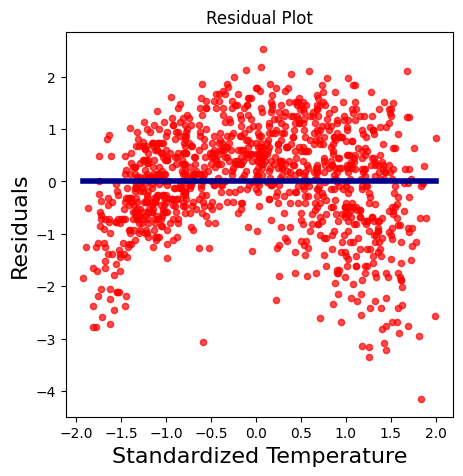

In [20]:
data = standardized_data.with_columns(
        "Fitted Value", fit(standardized_data, "Standardized Temperature", "Standardized Crowdedness"),
        "Residuals", residual(standardized_data, "Standardized Temperature", "Standardized Crowdedness")
    )

residual_table = Table().with_columns(
    "Standardized Temperature", data.column("Standardized Temperature"),
    "Residuals", data.column("Residuals")
)
residual_table.scatter("Standardized Temperature", "Residuals", color="r")
xlims = make_array(min(data.column("Standardized Temperature")), max(data.column("Standardized Temperature")))
plots.plot(xlims, make_array(0, 0), color="darkblue", lw=4)
plots.title("Residual Plot");

## Question 2b - 1 Point

Why does the scatterplot of **Standardized Temperature** and **Residuals** look similar to the scatterplot of **Standardized Temperature** and **Standardized Crowdedness**?

**Your Answer Here -** The scatterplot of standardized temperature and residuals  looks similar to the original plot because the residuals represent the part of the relationship not explained by the linear model. Since the relationship between temperature and crowdedness appears quadratic, the linear regression line does not capture this pattern. Beacause of this, the residuals still display the same cureved structure as in the original plot. 

## Question 3 - 2 Points

After viewing the residuals plot and using your data science knowledge, you suspect that this relationship will likely be more accurately modelled using a quadratic equation. 

Calculate the best fitting quadratic equation that predicts **Standardized Crowdedness** from **Standardized Temperature**. (Hint: Consider using the *minimize* function!). Create an overlaid scatterplot, showing the original data and this curve.

In [ ]:
# Place answer here.

## Question 4 - 2 Points

Develop an insightful visualization that uses the provided csv file, Chapter 15 knowledge, and any other data science knowledge that you have previously learned. Explain your visualization and what makes it insightful.

In [ ]:
# Place answer here.